✅ Dataset Loaded Successfully
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647

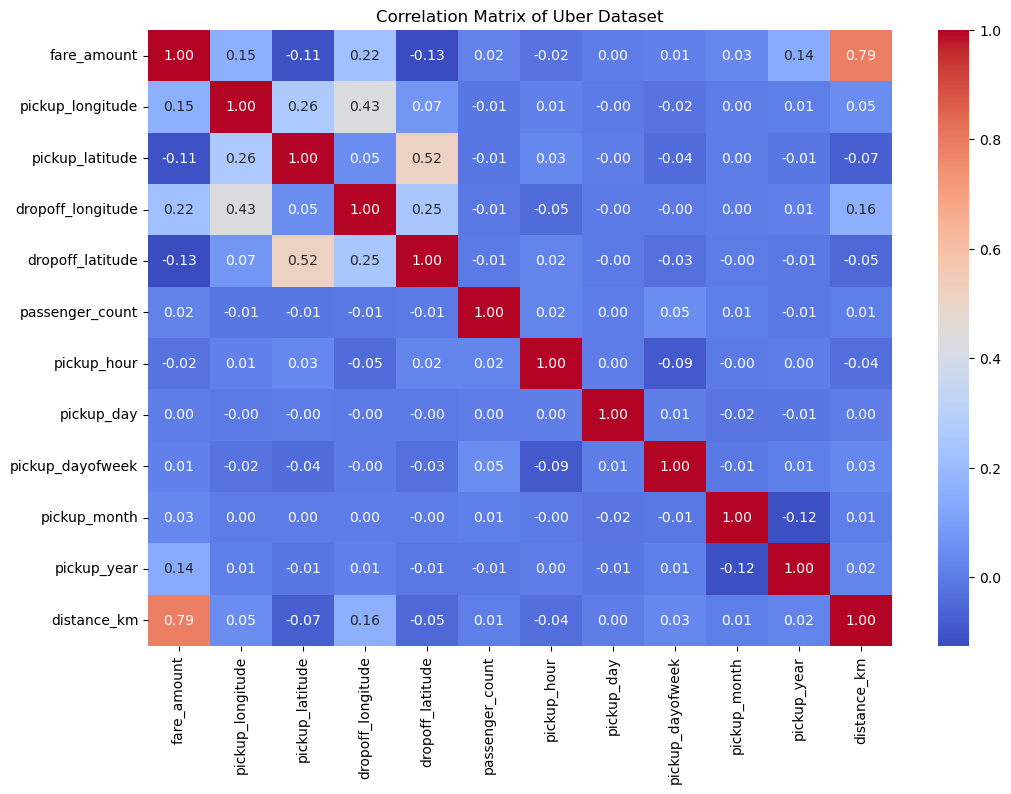


Linear Regression: R2 = 0.6563, RMSE = 3.19

Ridge Regression: R2 = 0.6563, RMSE = 3.19

Lasso Regression: R2 = 0.6541, RMSE = 3.20


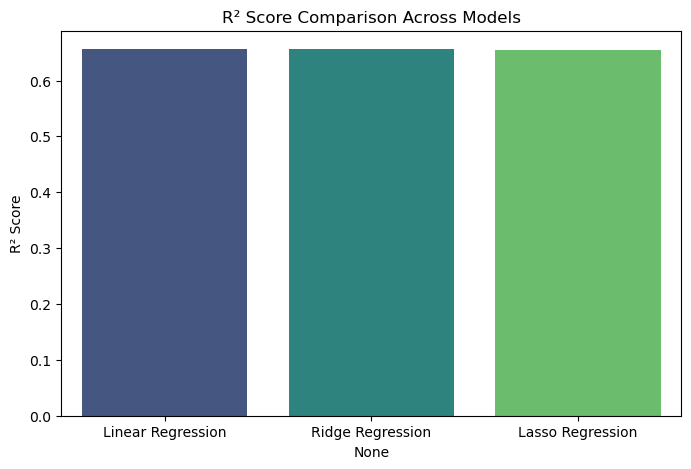

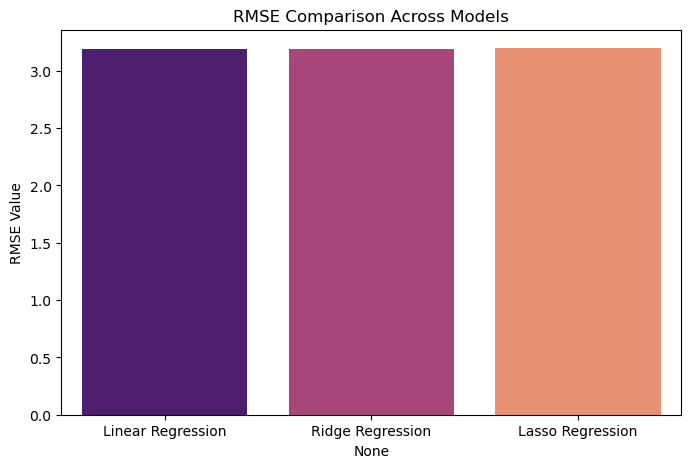

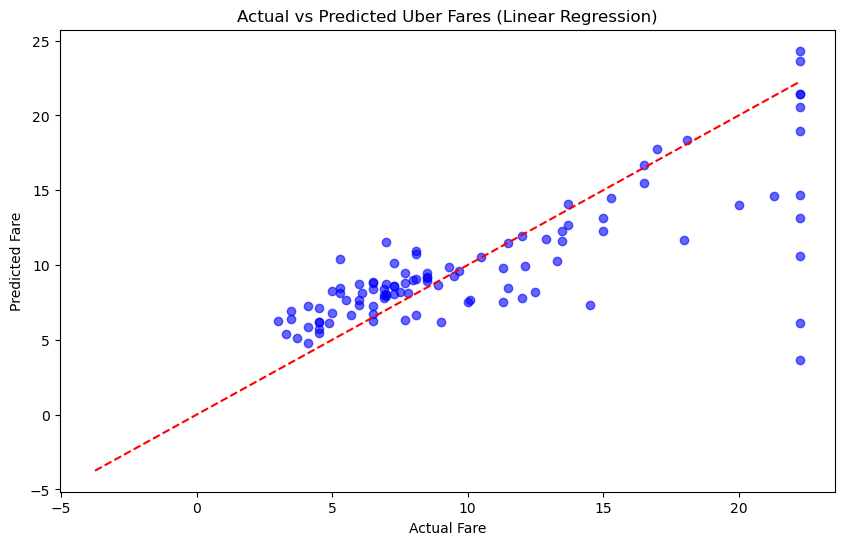


✅ Model Evaluation Summary:
                   R2 Score      RMSE
Linear Regression  0.656283  3.188832
Ridge Regression   0.656283  3.188832
Lasso Regression   0.654142  3.198746

💾 Best Model Saved as uber_fare_model.pkl


In [5]:
#%% ----------------------------------------------
# 🚕 Uber Fare Price Prediction using Regression Models
# Objective: Predict the price of an Uber ride based on pickup & dropoff details
# Dataset: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset
#-----------------------------------------------

# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import haversine as hs
import warnings
warnings.filterwarnings("ignore")

#%% Step 2: Load Dataset
df = pd.read_csv("uber.csv")   # Ensure file name matches your dataset
print("✅ Dataset Loaded Successfully")
print(df.head())

#%% Step 3: Initial Data Check
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
# --- Task 1: Pre-process the dataset ---

# Load data
df = pd.read_csv('uber.csv')

# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'key'])

# Handle missing values by dropping the few rows that have them
df = df.dropna()

# --- !!! NEW FIX (Added 4 lines) !!! ---
# Clean up impossible coordinate values *before* calculating distance
# A longitude must be between -180 and 180
# A latitude must be between -90 and 90
df = df[df['pickup_latitude'].between(-90, 90)]
df = df[df['pickup_longitude'].between(-180, 180)]
df = df[df['dropoff_latitude'].between(-90, 90)]
df = df[df['dropoff_longitude'].between(-180, 180)]
# --- End of Fix ---


# --- Feature Engineering (Part of Pre-processing) ---

# 1. Convert 'pickup_datetime' to datetime object
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# 2. Extract time-based features
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

# 3. Calculate distance using the haversine formula
def calculate_distance(row):
    pickup = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff = (row['dropoff_latitude'], row['dropoff_longitude'])
    return hs.haversine(pickup, dropoff)

# This line will now work correctly
df['distance_km'] = df.apply(calculate_distance, axis=1)

# 4. Clean up the final features
# We drop the original columns because we have the new, better features
df = df.drop(columns=[
    'pickup_datetime', 
    'pickup_longitude', 
    'pickup_latitude', 
    'dropoff_longitude', 
    'dropoff_latitude'
])

# 5. Clean data (remove impossible values)
# Remove fares that are 0 or less
df = df[df['fare_amount'] > 0]
# Remove rows with 0 distance
df = df[df['distance_km'] > 0]

print("--- Pre-processing Complete ---")
df.head()
# %%
# --- Task 2: Identify Outliers ---

print("\n--- Identifying Outliers (before treatment) ---")
# We will focus on 'fare_amount' and 'distance_km'
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['fare_amount'])
plt.title('Boxplot for fare_amount')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['distance_km'])
plt.title('Boxplot for distance_km')
plt.show()

# --- Treating Outliers ---
# We will use the IQR method to clip extreme values (like in Code 1)
def clip_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Clip values to be within the lower and upper bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Only apply outlier treatment to 'fare_amount' and 'distance_km'
df = clip_outliers(df, 'fare_amount')
df = clip_outliers(df, 'distance_km')

print("\n--- Outliers Treated ---")
# Show boxplots again after treatment
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['fare_amount'])
plt.title('Boxplot for fare_amount (After)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['distance_km'])
plt.title('Boxplot for distance_km (After)')
plt.show()

#%% Step 4: Data Cleaning & Feature Engineering
# Drop unnecessary columns
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
if 'key' in df.columns:
    df = df.drop(columns=['key'])

# Convert pickup_datetime to datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

# Extract datetime features
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year
df = df.drop(columns=['pickup_datetime'])

#%% Step 5: Handle Missing Values
imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\n✅ Missing values handled successfully!")

#%% Step 6: Outlier Detection & Treatment (IQR Method)
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower, upper)
    return data

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df = remove_outliers_iqr(df, col)

print("\n✅ Outliers treated successfully!")

#%% Step 7: Add Distance Feature using Haversine Formula
def calculate_distance(row):
    pickup = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff = (row['dropoff_latitude'], row['dropoff_longitude'])
    return hs.haversine(pickup, dropoff)

df['distance_km'] = df.apply(calculate_distance, axis=1)
print("\n📍 Distance feature added successfully!")

#%% Step 8: Correlation Analysis
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Uber Dataset")
plt.show()

#%% Step 9: Split Features and Target
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#%% Step 10: Train Regression Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"R2 Score": r2, "RMSE": rmse}
    print(f"\n{name}: R2 = {r2:.4f}, RMSE = {rmse:.2f}")

#%% Step 11: Visualize Model Comparison
result_df = pd.DataFrame(results).T
plt.figure(figsize=(8,5))
sns.barplot(x=result_df.index, y=result_df["R2 Score"], palette="viridis")
plt.title("R² Score Comparison Across Models")
plt.ylabel("R² Score")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=result_df.index, y=result_df["RMSE"], palette="magma")
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE Value")
plt.show()

#%% Step 12: Visualize Actual vs Predicted Fare
best_model = LinearRegression().fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(10,6))
plt.scatter(y_test[:100], y_pred_best[:100], color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Uber Fares (Linear Regression)")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.show()

#%% Step 13: Summary Table
print("\n✅ Model Evaluation Summary:")
print(result_df)

#%% Step 14: Save the Best Model
import joblib
joblib.dump(best_model, "uber_fare_model.pkl")
print("\n💾 Best Model Saved as uber_fare_model.pkl")


✅ Dataset Loaded Successfully
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647

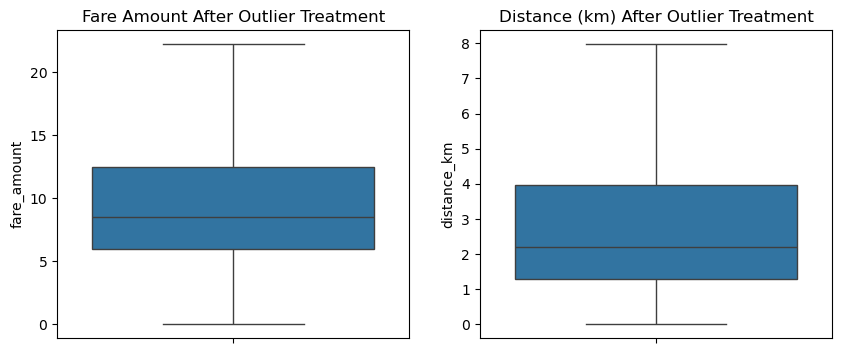

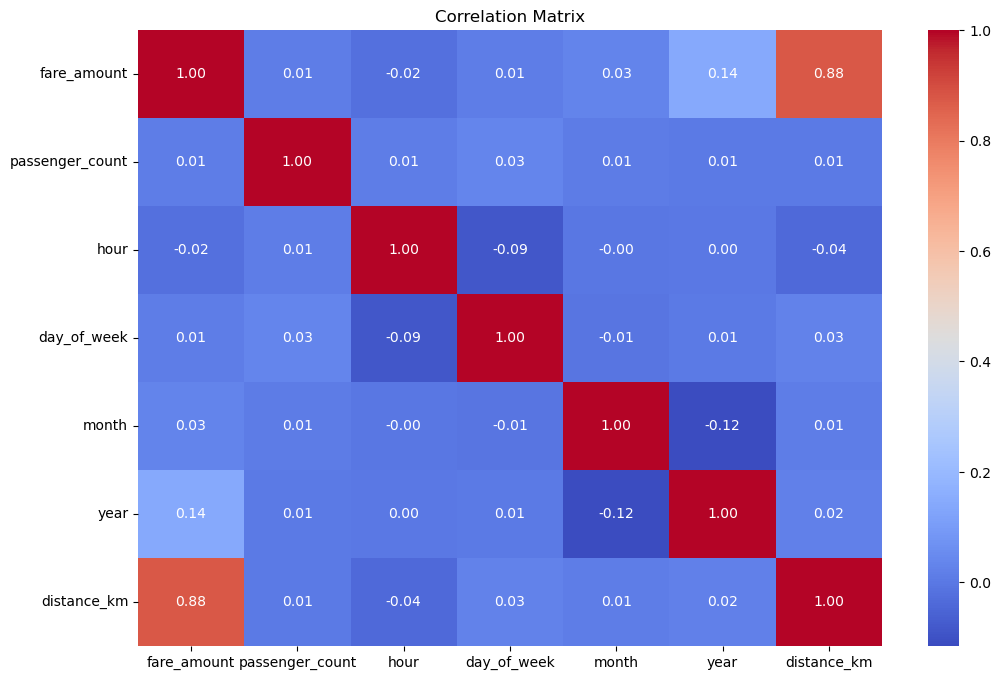

Linear Regression: R² = 0.7831, RMSE = 2.53
Ridge Regression: R² = 0.7831, RMSE = 2.53
Lasso Regression: R² = 0.7817, RMSE = 2.54


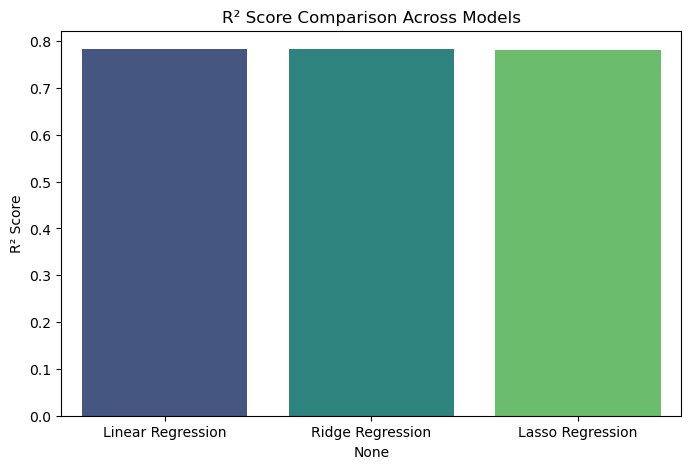

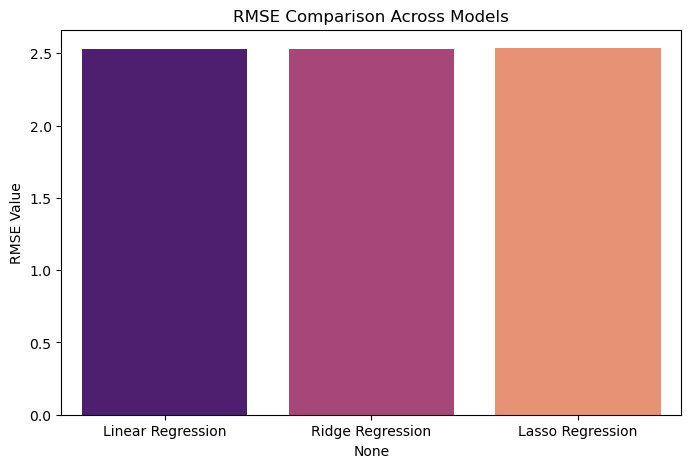

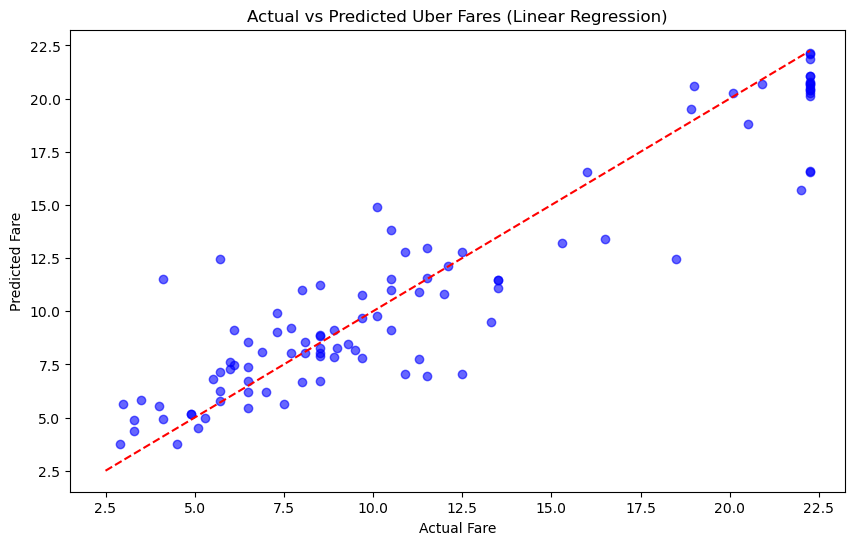


✅ Model Evaluation Summary:
                   R2 Score      RMSE
Linear Regression  0.783133  2.528656
Ridge Regression   0.783133  2.528656
Lasso Regression   0.781740  2.536764

💾 Best Model Saved as uber_fare_model.pkl


In [8]:
#%% ---------------------------------------------------
# 🚕 Uber Fare Price Prediction using Regression Models
# Objective: Predict Uber ride fare based on pickup/dropoff details
# Dataset: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset
# ---------------------------------------------------

# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# Custom Haversine Function (no need to install external package)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


#%% Step 2: Load Dataset
df = pd.read_csv("uber.csv")   # Use your dataset path here
print("✅ Dataset Loaded Successfully")
print(df.head())

#%% Step 3: Initial Data Check
print("\n--- Dataset Info ---")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

#%% Step 4: Data Cleaning and Preprocessing
# Drop unnecessary columns if present
df = df.drop(columns=['Unnamed: 0', 'key'], errors='ignore')

# Handle missing values (using mean imputation)
imputer = SimpleImputer(strategy='mean')
df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']] = \
    imputer.fit_transform(df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']])

# Remove invalid coordinates
df = df[df['pickup_latitude'].between(-90, 90)]
df = df[df['pickup_longitude'].between(-180, 180)]
df = df[df['dropoff_latitude'].between(-90, 90)]
df = df[df['dropoff_longitude'].between(-180, 180)]

# Convert datetime and extract features
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year

#%% Step 5: Feature Engineering
# Calculate distance using Haversine Formula
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Drop original coordinate and datetime columns
df = df.drop(columns=['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 
                      'dropoff_longitude', 'dropoff_latitude'])

# Remove zero or negative fares/distances
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]

print("\n✅ Preprocessing complete. Dataset shape:", df.shape)
print(df.head())

#%% Step 6: Outlier Detection & Treatment (IQR Method)
def clip_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower, upper)
    return data

# Apply to main numeric columns
for col in ['fare_amount', 'distance_km']:
    df = clip_outliers(df, col)

print("\n✅ Outliers treated successfully!")

# Visualize after treatment
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['fare_amount'])
plt.title('Fare Amount After Outlier Treatment')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['distance_km'])
plt.title('Distance (km) After Outlier Treatment')
plt.show()

#%% Step 7: Correlation Analysis
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#%% Step 8: Split Data for Modeling
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#%% Step 9: Train Models (Linear, Ridge, Lasso)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {"R2 Score": r2, "RMSE": rmse}
    print(f"{name}: R² = {r2:.4f}, RMSE = {rmse:.2f}")

#%% Step 10: Visualize Model Performance
result_df = pd.DataFrame(results).T

plt.figure(figsize=(8,5))
sns.barplot(x=result_df.index, y=result_df["R2 Score"], palette="viridis")
plt.title("R² Score Comparison Across Models")
plt.ylabel("R² Score")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=result_df.index, y=result_df["RMSE"], palette="magma")
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE Value")
plt.show()

#%% Step 11: Visualize Actual vs Predicted (Best Model)
best_model = LinearRegression().fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(10,6))
plt.scatter(y_test[:100], y_pred_best[:100], color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Uber Fares (Linear Regression)")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.show()

#%% Step 12: Summary Table
print("\n✅ Model Evaluation Summary:")
print(result_df)

#%% Step 13: Save the Best Model
import joblib
joblib.dump(best_model, "uber_fare_model.pkl")
print("\n💾 Best Model Saved as uber_fare_model.pkl")
